# Hospital Geographic and Time-series Analysis
Explore monthly admissions, yearly cost trends, and regional condition patterns.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("hospital.csv")
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"], dayfirst=True)
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"], dayfirst=True)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15372\1959671189.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Month", order=month_order, palette="magma")


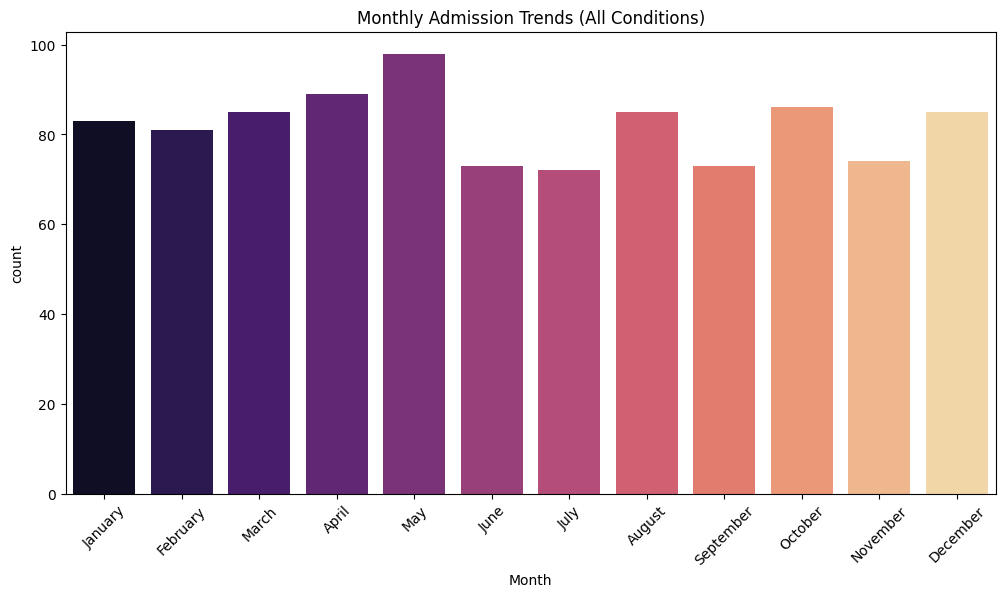

In [ ]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
df["Month"] = pd.Categorical(df["Admission_Date"].dt.month_name(), categories=month_order, ordered=True)
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x="Month",
    order=month_order,
    hue="Month",
    legend=False,
    palette="magma"
)
plt.title("Monthly Admission Trends (All Conditions)")
plt.xticks(rotation=45)
plt.show()


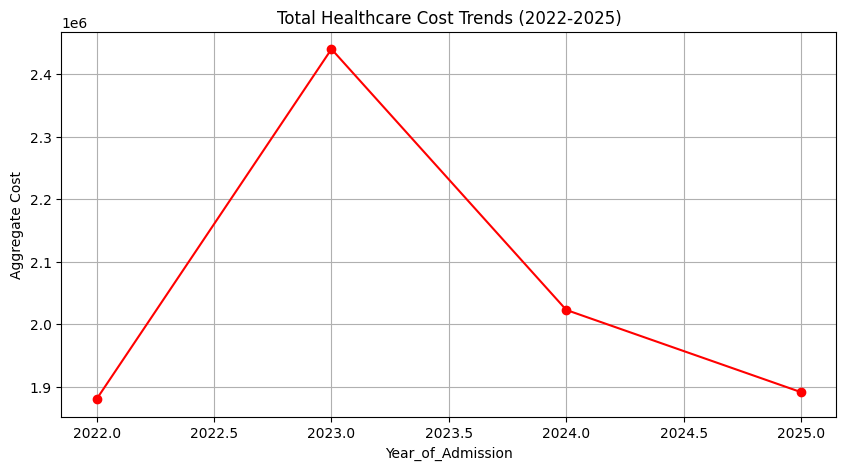

In [ ]:
yearly_costs = df.groupby("Year_of_Admission")["Total_Cost"].sum()
plt.figure(figsize=(10, 5))
yearly_costs.plot(kind="line", marker="o", color="red")
plt.title("Total Healthcare Cost Trends (2022-2025)")
plt.ylabel("Aggregate Cost")
plt.grid(True)
plt.show()


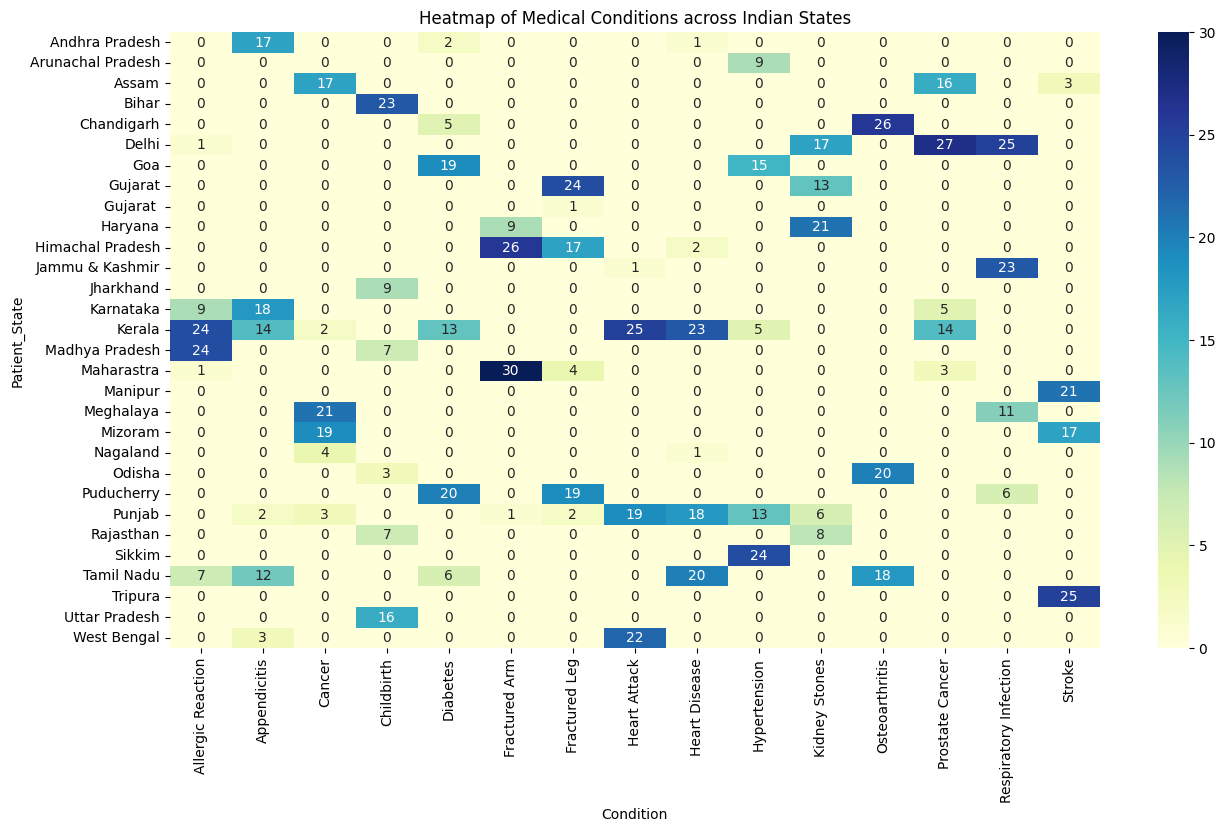

In [ ]:
state_condition = df.groupby(["Patient_State", "Condition"]).size().unstack().fillna(0)
plt.figure(figsize=(15, 8))
sns.heatmap(state_condition, annot=True, cmap="YlGnBu", fmt="g")
plt.title("Heatmap of Medical Conditions across Indian States")
plt.show()


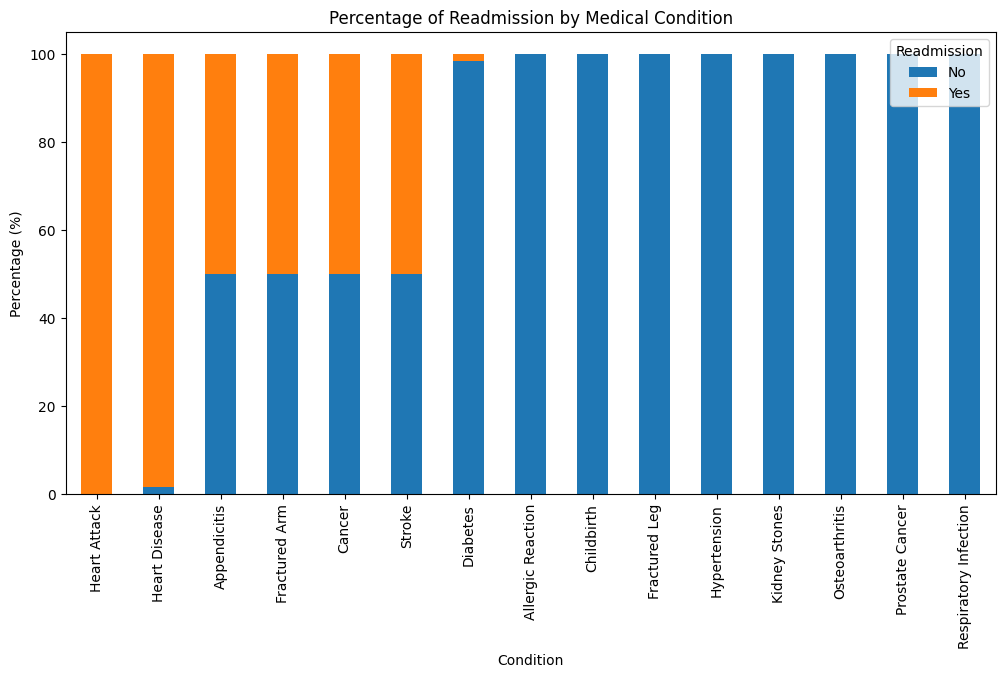

In [ ]:
readmission_pivot = df.groupby("Condition")["Readmission"].value_counts(normalize=True).unstack() * 100
readmission_pivot.sort_values("Yes", ascending=False).plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Percentage of Readmission by Medical Condition")
plt.ylabel("Percentage (%)")
plt.show()


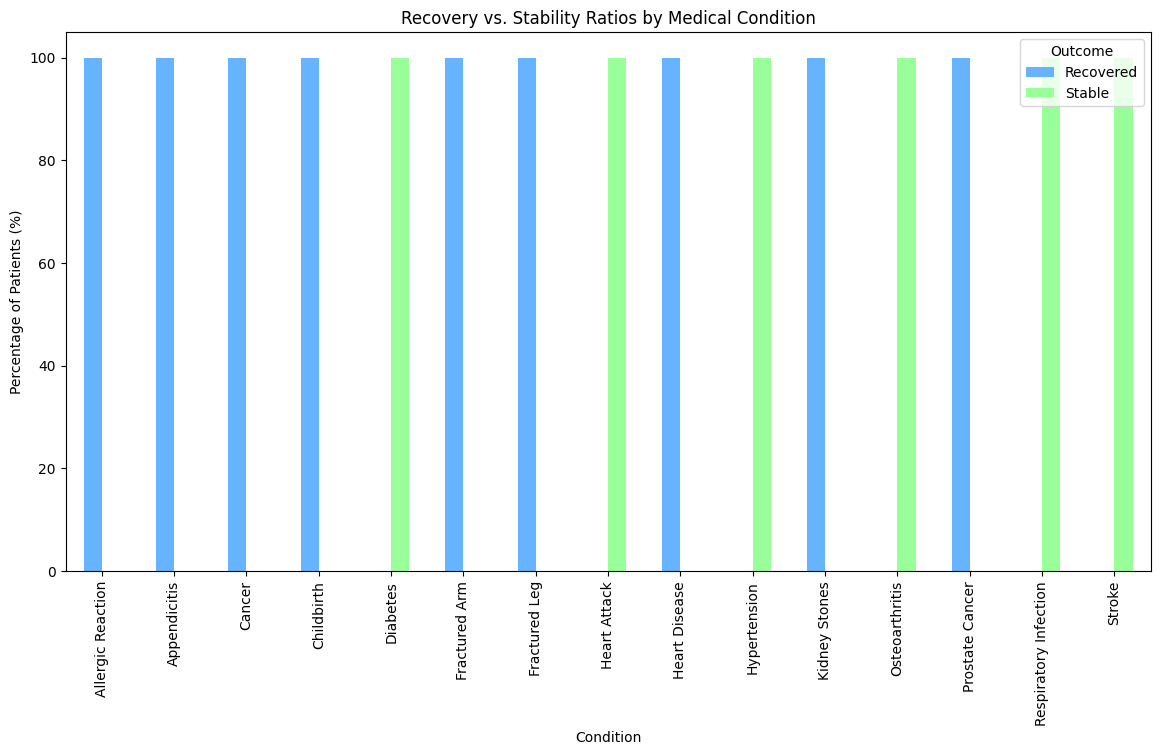

In [ ]:
outcome_stats = df.groupby("Condition")["Outcome"].value_counts(normalize=True).unstack() * 100
outcome_stats.plot(kind="bar", figsize=(14, 7), color=["#66b3ff", "#99ff99"])
plt.title("Recovery vs. Stability Ratios by Medical Condition")
plt.ylabel("Percentage of Patients (%)")
plt.legend(title="Outcome")
plt.show()
